# Quantum Phase Estimation Workbench Implementation
This tutorial outlines the way quantum phase estimation is implemented in Workbench Algorithms and the way users are expected to interact with it. It is *not* intended to be a tutorial on the conceptual framework behind QPE.

## What do we want?
In QPE we want to take some unitary $U$ and extract its eigenphase $e^{2\pi i \phi}$. Our goal is to obtain a `bits_of_precision`-bit estimate of the eigenphase $\phi$, loaded into a quantum register.

### A note on datatypes:
Typically in Workbench we think of `Qubits` objects as unsigned quantum integers, that is measuring the bitstring `1101` corresponds to the value `1*1 + 1*2 + 0*4 + 1*8 = 11`. However, this is not the only datatype we are interested in! We can also have unsigned fixed point numbers, which are convenient for storing the eigenphase output from QPE. In this tutorial, we focus on fixed point numbers with radix equal to the length of the bit string, meaning that we interpret the string of measurements `1101` to mean `1/2 + 1/4 + 0/8 + 1/16 = 0.8125`. This conversion is automatically handled using the `QUFixed` data type in Workbench.

## How can we do this?
There are four different types of QPE that we can use in Workbench Algorithms:

1. Vanilla QPE (`QPE`): Textbook QPE, with controlled unitary applications followed by inverse quantum Fourier transform.
2. Iterative QPE(`IterativeQPE`): QPE where each phase bit is measured sequentially and used to "break up" the inverse QFT.
3. Coherent iterative QPE (`CoherentIterativeQPE`): Same concept as iterative QPE, but the rotations required to implement the inverse QFT are performed coherently using controls.
4. Double Phase Kickback QPE (`DoublePhaseKickbackQPE`): This version of QPE only works for when using Qubitization and it uses a double-phase kickback trick in order to reduce the number of calls to the unitary by a factor of 2.

In the first set of examples, we will use a simple $Rz(\phi) = \exp(-i\phi/2)$ gate to demonstrate the setup for each routine, but any unitary can be substituted in. The final example will show how straightforward this is by swapping to a qubitized unitary. This unitary is defined below:

In [1]:
from psiqworkbench import QPU, QUInt, QUFixed, Qubrick
from workbench_algorithms import (
    QPE,
    CoherentIterativeQPE,
    IterativeQPE,
    DoublePhaseKickbackQPE,
    LCU,
    Qubitization,
    QubitizedWalkOperator,
    PrepareNaive,
    SelectNaive
)
from workbench_algorithms.utils import (
    get_exactly_representable_qubitized_hamiltonian,
    phase_to_energy_qubitization
)
import numpy as np

In [2]:
class SimplePhaseUnitary(Qubrick):
    """Returns a Qubrickified ``Rz`` gate for debugging QPE routines.

    Allows for exact eigenphases to be implemented in QPE.

    Args:
        params (dict): Parameters that the Qubrick can access. May contain ``phase``.
    """

    def __init__(self, phase, **kwargs):
        self.phase = phase
        super().__init__(**kwargs)

    def _compute(self, psi, ctrl=0):
        """Compute the dummy block encoding.

        Args:
            psi (Qubits): State register for the computation.
            ctrl (int, Qubits): Register to control the unitary on. Defaults to ``0``.
        """
        phase = self.phase

        theta = 2 * 360 * phase

        self.get_qc().rz(theta, psi, ctrl)

## 1. [Vanilla QPE](../autoapi/workbench_algorithms/subroutines/quantum_phase_estimation.html#workbench_algorithms.subroutines.quantum_phase_estimation.QPE)

In [3]:
# define some constants and set up unitary
bits_of_precision = 5
phase = 1/2 + 1/4 + 1/16  # corresponds to exactly representable bitstring 1101
unitary = SimplePhaseUnitary(phase=phase)

# set up the quantum register
qc = QPU()
qc.reset(bits_of_precision + 1)
psi = QUInt(1, "psi", qc)  # QUInt for the system reg
phase_qubits = QUFixed(bits_of_precision, bits_of_precision, "phase_reg", qc)

# initialize the QPE qubrick
qpe = QPE(bits_of_precision=bits_of_precision, unitary=unitary)

# apply x to flip the sign of the eigenstate
psi.x()

# compute the QPE
qpe.compute(psi, phase_qubits)

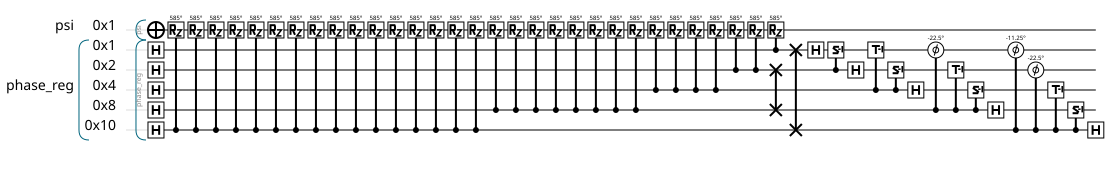

In [4]:
# draw the circuit
qc.draw()

In [5]:
# check that the output is correct
print(phase == phase_qubits.read())

True


## 2. [Iterative QPE](../autoapi/workbench_algorithms/subroutines/quantum_phase_estimation.html#workbench_algorithms.subroutines.quantum_phase_estimation.IterativeQPE)
*Note that for iterative QPE we should be able to use a single ancilla to load the phases, but this is not currently supported.*

In [6]:
# define some constants and set up unitary
bits_of_precision = 5
phase = 1/2 + 1/4 + 1/16  # corresponds to exactly representable bitstring 1101
unitary = SimplePhaseUnitary(phase=phase)

# set up the quantum register
qc = QPU()
qc.reset(bits_of_precision + 1)
psi = QUInt(1, "psi", qc)  # QUInt for the system reg
phase_qubits = QUFixed(bits_of_precision, bits_of_precision, "phase_reg", qc)

# initialize the QPE qubrick
qpe = IterativeQPE(bits_of_precision=bits_of_precision, unitary=unitary)

# apply x to flip the sign of the eigenstate
psi.x()

# compute the QPE
qpe.compute(psi, phase_qubits)

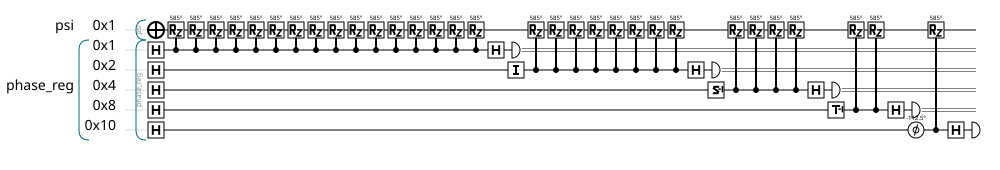

In [7]:
# draw the circuit
qc.draw()

In [8]:
# check that the output is correct
print(phase == phase_qubits.read())

True


## 3. [Coherent Iterative QPE](../autoapi/workbench_algorithms/subroutines/quantum_phase_estimation.html#workbench_algorithms.subroutines.quantum_phase_estimation.CoherentIterativeQPE)

In [9]:
# define some constants and set up unitary
bits_of_precision = 5
phase = 1/2 + 1/4 + 1/16  # corresponds to exactly representable bitstring 1101
unitary = SimplePhaseUnitary(phase=phase)

# set up the quantum register
qc = QPU()
qc.reset(bits_of_precision + 1)
psi = QUInt(1, "psi", qc)  # QUInt for the system reg
phase_qubits = QUFixed(bits_of_precision, bits_of_precision, "phase_reg", qc)

# initialize the QPE qubrick
qpe = CoherentIterativeQPE(bits_of_precision=bits_of_precision, unitary=unitary)

# apply x to flip the sign of the eigenstate
psi.x()

# compute the QPE
qpe.compute(psi, phase_qubits)

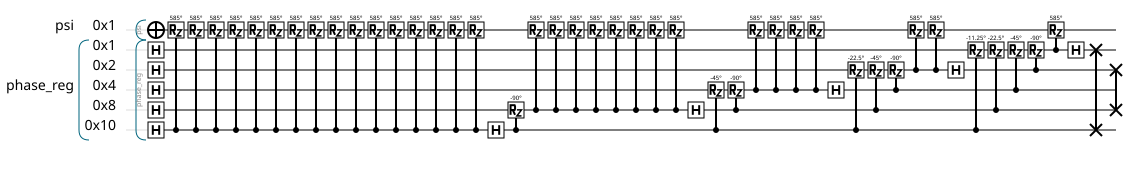

In [10]:
# draw the circuit
qc.draw()

In [11]:
# check that the output is correct
print(phase == phase_qubits.read())

True


## Extension to Qubitization
We can also use QPE to extract out the eigenphases of more complex unitaries by just swapping out the `unitary` part of the code -- everything else remains *almost* identical (we also need to pass some `**unitary_kwargs` to the `compute` call to ensure that the qubitization is implemented correctly). For this example, we will use a block encoding of a Hamiltonian which has been designed such that the arccos of its eigenvalue is exactly representable with `bits_of_precision` bits. The process is identical for any Hamiltonian, however.

In [12]:
# setting up our qubitized unitary
bits_of_precision = 3
alpha = 0.1  # arbitrary
ham, eigenvalue = get_exactly_representable_qubitized_hamiltonian(alpha=alpha, bits_of_precision=bits_of_precision)
print(eigenvalue)
print(ham)  # PauliSum representation

0.375
0.1*Z0
+ 0.0414213562373095*Z1
+ 0.1414213562373095*I


The previous step is purely to obtain a test Hamiltonian to block encode: to use this code for actual projects, simply replace `ham` with your Hamiltonian of choice and change the state prep portion of the code to implement the desired eigenstate.

In [13]:
# set up qubitized unitary
ham_amps = ham.get_coefficients()
prepare = PrepareNaive(coeffs=ham_amps)
select = SelectNaive()
block_encoding = LCU(state_prep=prepare, select=select)
unitary = Qubitization(block_encoding=block_encoding)

# set up the quantum register
qc = QPU()
qc.reset(int(ham.width() + np.ceil(np.log2(len(ham))) + bits_of_precision))  # system size + ancillae for select + phase bits
psi = QUInt(2, "psi", qc)  # QUInt for the system reg
be_ancilla_reg = QUInt(int(np.ceil(np.log2(len(ham)))), "be_ancilla_reg", qc)
phase_qubits = QUFixed(bits_of_precision, bits_of_precision, "phase_reg", qc)

# set up eigenstate - CHANGE FOR OTHER SYSTEMS
psi[1].x()

# initialize the QPE qubrick
qpe = QPE(bits_of_precision=bits_of_precision, unitary=unitary)

# compute the QPE
qpe.compute(psi, phase_qubits, **{"be_ancilla_reg": be_ancilla_reg, "data": ham})

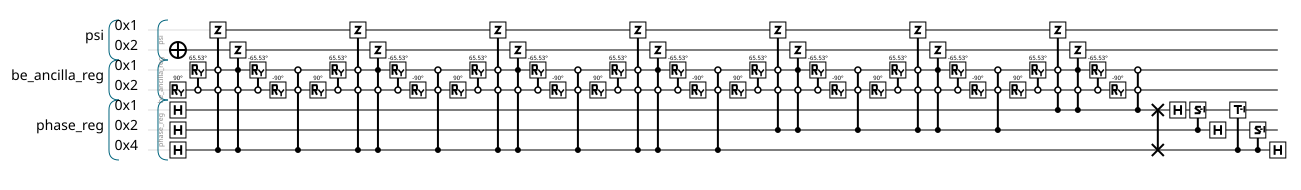

In [14]:
# draw the circuit
qc.draw()

Since we've used a qubitization iterate, we can't just compare the eigenphase we generated earlier to the output: we need to undo the arccos that comes from qubitization.

In [15]:
# compare true value to measured value
print(np.isclose(eigenvalue, phase_to_energy_qubitization(phase_qubits.read(), ham.norm()) / ham.norm()))  # numerical error means == doesn't work
print(eigenvalue, phase_to_energy_qubitization(phase_qubits.read(), ham.norm()) / ham.norm())

False
0.375 0.7071067811865475


## 4. [Double Phase Kickback QPE](../autoapi/workbench_algorithms/subroutines/quantum_phase_estimation.html#workbench_algorithms.subroutines.quantum_phase_estimation.CoherentIterativeQPE)

The main advantage of using `DoublePhaseKickbackQPE` is that it reduces the number of calls to our unitary by about a factor of 2. This is because it employs a double-phase kickback trick which is outlined in [Figure 2 of this paper](https://arxiv.org/abs/1805.03662). In `DoublePhaseKickbackQPE`, we must also use the `QubitizedWalkOperator` as our unitary. One key difference however versus using the standard `Qubitization` `Qubrick` (as shown above) is that you must call your PREPARE `Qubrick` first, before running `QubitizedWalkOperator`.

In [16]:
# set up qubitized unitary
ham_amps = ham.get_coefficients()
prepare = PrepareNaive(coeffs=ham_amps)
select = SelectNaive()
unitary = QubitizedWalkOperator(state_prep=prepare, select=select)

# set up the quantum register
qc = QPU()
qc.reset(int(ham.width() + np.ceil(np.log2(len(ham))) + bits_of_precision))  # system size + ancillae for select + phase bits
psi = QUInt(2, "psi", qc)  # QUInt for the system reg
be_ancilla_reg = QUInt(int(np.ceil(np.log2(len(ham)))), "be_ancilla_reg", qc)
phase_qubits = QUFixed(bits_of_precision, bits_of_precision, "phase_reg", qc)

# set up eigenstate - CHANGE FOR OTHER SYSTEMS
psi[1].x()

# initialize the DoublePhaseKickbackQPE qubrick 
# NOTE: we need to pass in the prepare Qubrick from our block-encoding as well!
qpe = DoublePhaseKickbackQPE(bits_of_precision=bits_of_precision, unitary=unitary)

# call PREPARE first since we are using QubitizedWalkOperator 
prepare.compute(be_ancilla_reg)

# compute the QPE
qpe.compute(psi, phase_qubits, **{"be_ancilla_reg": be_ancilla_reg, "data": ham})

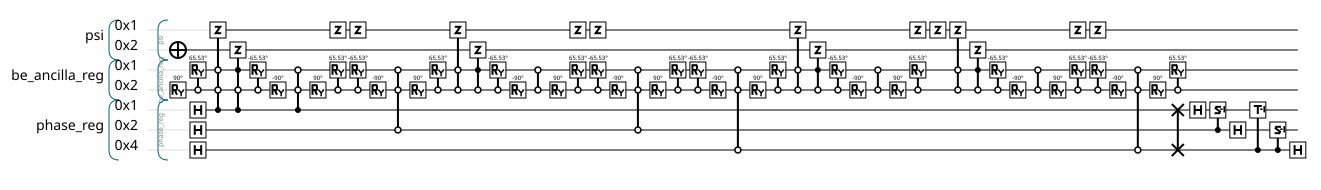

In [17]:
# draw the circuit
qc.draw()

When looking at this circuit, we can see that our unitary (`QubitizedWalkOperator`) is only applied 4 times as compared to the 7 times that the unitary (`Qubitization`) is applied when using traditional `QPE` using `Qubitization`.

In [18]:
# compare true value to measured value
print(np.isclose(eigenvalue, phase_to_energy_qubitization(phase_qubits.read(), ham.norm()) / ham.norm()))  # numerical error means == doesn't work
print(eigenvalue, phase_to_energy_qubitization(phase_qubits.read(), ham.norm()) / ham.norm())

False
0.375 0.7071067811865477
